In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [3]:

def aux(temp):
    if temp<=80:
        return 'lento'
    elif temp <=120:
        return 'moderado'
    return 'rapido'

df['duration_ms']= df['duration_ms']/60000
df['duration_ms_ar'] = df['duration_ms_ar']/60000
df['duration_ms_yr'] = df['duration_ms_yr']/60000

"""df['energy_ratio_yr'] = df['energy_yr']*df['acousticness_yr']
df['electro_focus_yr'] = (1-df['acousticness_yr'])*df['energy_yr']*df['instrumentalness_yr']
df['vocal_energy_yr'] = (1-df['instrumentalness_yr'])*df['energy_yr']

df['energy_ratio_'] = df['energy']*df['acousticness']
df['electro_focus'] = (1-df['acousticness'])*df['energy']*df['instrumentalness']
df['vocal_energy'] = (1-df['instrumentalness'])*df['energy']

df['energy_ratio_ar'] = df['energy_ar']*df['acousticness_ar']
df['electro_focus_ar'] = (1-df['acousticness_ar'])*df['energy_ar']*df['instrumentalness_ar']
df['vocal_energy_ar'] = (1-df['instrumentalness_ar'])*df['energy_ar']
df['enegy_per_bpm'] = df['energy']/(df['tempo']+1e-6)
df['harmonic_purity'] = df['acousticness']*df['instrumentalness']
df['ryhtmic_pulse'] = (df['tempo']*df['danceability'])/100
df['music_beats_estimated'] = (df['duration_ms']/1000)*(df['tempo']/60)
"""

df['temp_range'] = df['tempo_yr'].apply(aux)
df = pd.get_dummies(df,columns=['temp_range'],prefix='temp')
df[['temp_moderado','temp_rapido']] = df[['temp_moderado','temp_rapido']].astype(int)

In [4]:
df.head()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,mode,key_0_yr,key_1_yr,key_2_yr,key_3_yr,key_4_yr,key_5_yr,key_6_yr,temp_moderado,temp_rapido
0,0.0131,0.2560,3.039117,0.895,0,0.000106,0.0821,-4.860,29,0.0707,...,1,0,0,1,0,0,0,0,0,1
1,0.9800,0.2770,3.449533,0.145,0,0.879000,0.1110,-19.898,0,0.0845,...,1,1,0,0,0,0,0,0,1,0
2,0.7950,0.6850,5.244450,0.483,0,0.878000,0.1130,-10.202,1,0.0337,...,1,0,0,0,1,0,0,0,1,0
3,0.6560,0.7880,2.995783,0.808,0,0.000000,0.1540,-6.590,0,0.0395,...,1,0,0,0,1,0,0,0,1,0
4,0.3020,0.0753,8.309333,0.150,0,0.884000,0.1210,-16.705,0,0.0371,...,1,1,0,0,0,0,0,0,1,0


In [5]:
df.describe()

,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,liveness,loudness,popularity,speechiness,...,mode,key_0_yr,key_1_yr,key_2_yr,key_3_yr,key_4_yr,key_5_yr,key_6_yr,temp_moderado,temp_rapido
count,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,...,172230.0,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000,172230.000000
mean,0.501914,0.536246,3.877864,0.480989,0.067956,0.194968,0.211396,-11.777780,25.925913,0.105896,...,1.0,0.365111,0.058857,0.096325,0.052262,0.329356,0.092243,0.005847,0.590913,0.409087
std,0.379394,0.175858,2.452947,0.272032,0.251670,0.332974,0.180661,5.690105,21.866745,0.183053,...,0.0,0.481463,0.235358,0.295037,0.222555,0.469981,0.289369,0.076241,0.491667,0.491667
min,0.000000,0.000000,0.082283,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.091300,0.414000,2.770000,0.248000,0.000000,0.000000,0.099300,-14.935750,1.000000,0.035200,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.523000,0.547000,3.428625,0.463000,0.000000,0.000498,0.138000,-10.867000,26.000000,0.045400,...,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.896000,0.668000,4.426667,0.708000,0.000000,0.238000,0.270000,-7.532000,42.000000,0.076000,...,1.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,0.996000,0.988000,88.971700,1.000000,1.000000,1.000000,1.000000,3.855000,100.000000,0.971000,...,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df['mode'].max()

np.int64(1)

In [8]:
df['mode'].min()

np.int64(1)

In [9]:
df = df.drop(columns=['mode'])
#[f'key_{x}' for x in range(1,12)]+[f'key_{x}_ar' for x in range(0,12)]+[f'key_{x}_yr' for x in range(0,7)]+['key_0']

In [10]:
corr = df.corr()

<Axes: >

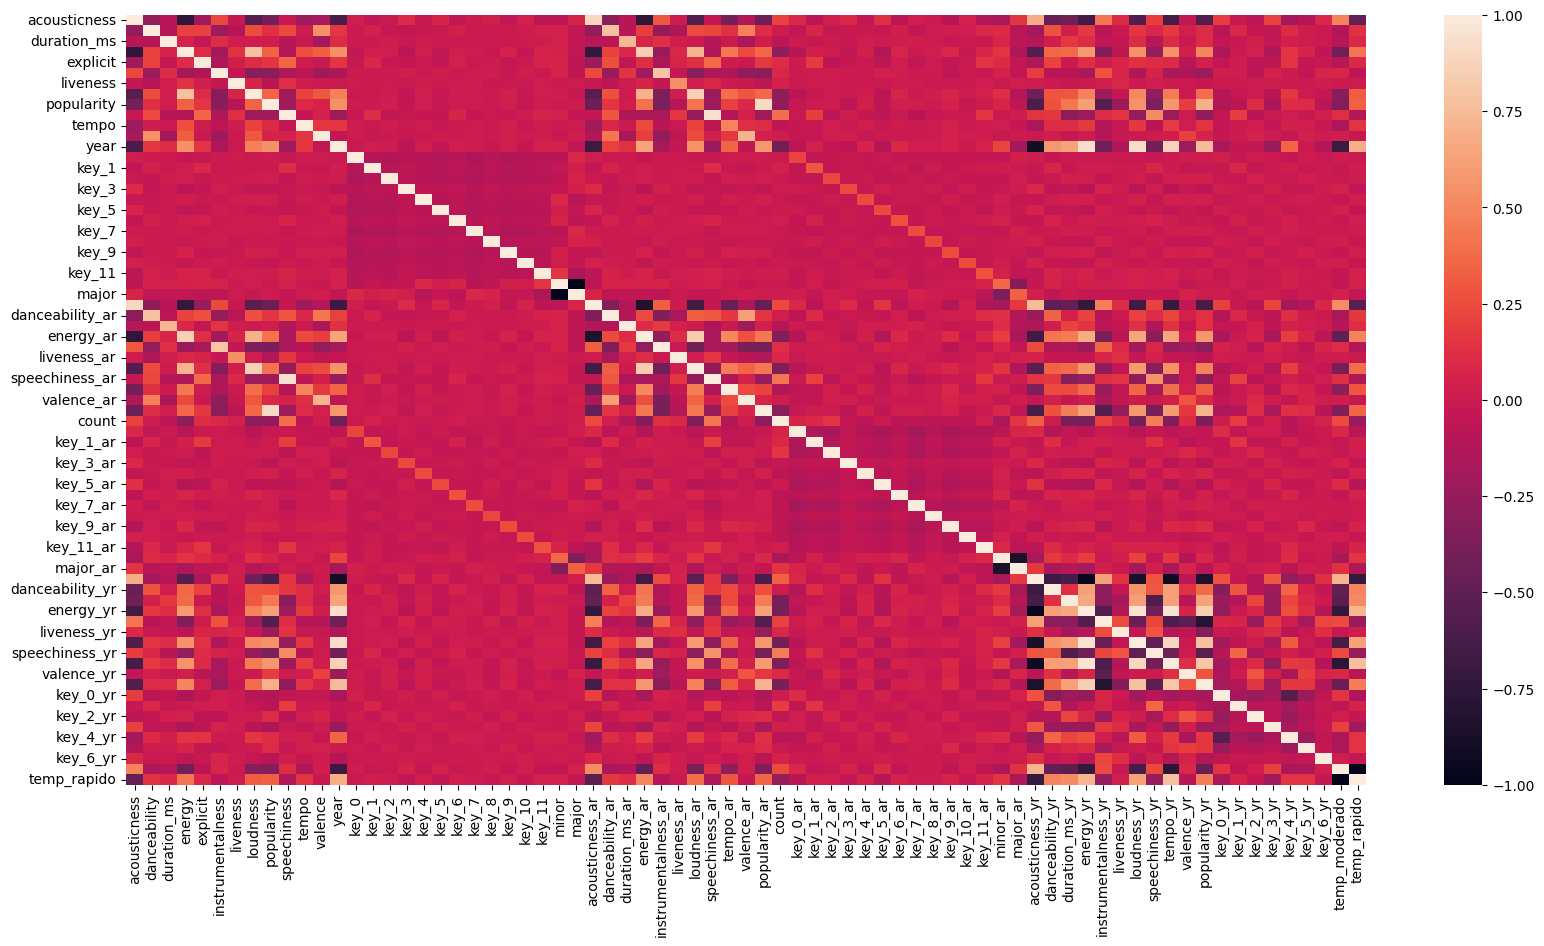

In [11]:
plt.figure(figsize=(20,10))
sns.heatmap(corr)

<Axes: ylabel='Frequency'>

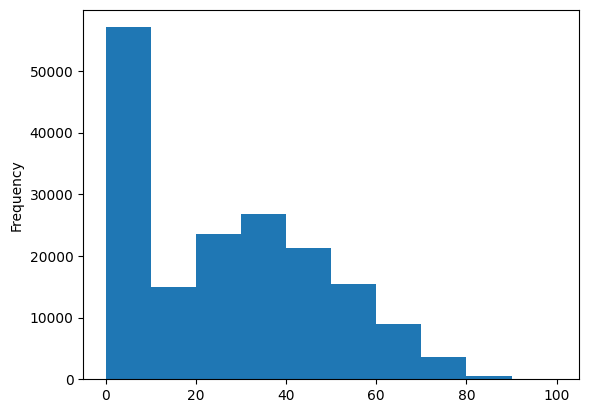

In [12]:
df['popularity'].plot(kind='hist')

In [13]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()


def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


<Axes: ylabel='Frequency'>

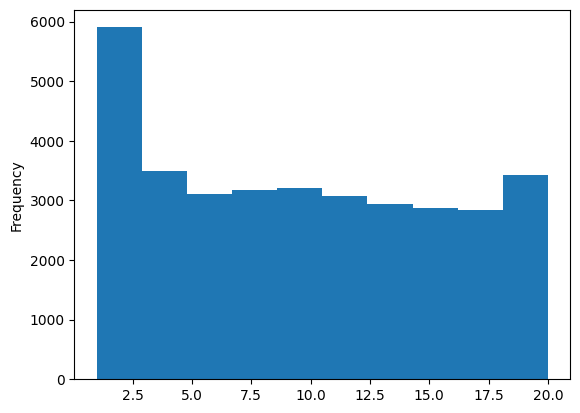

In [14]:
df_processed[df_processed['popularity_multiclass']==1]['popularity'].plot(kind='hist')


<Axes: ylabel='Frequency'>

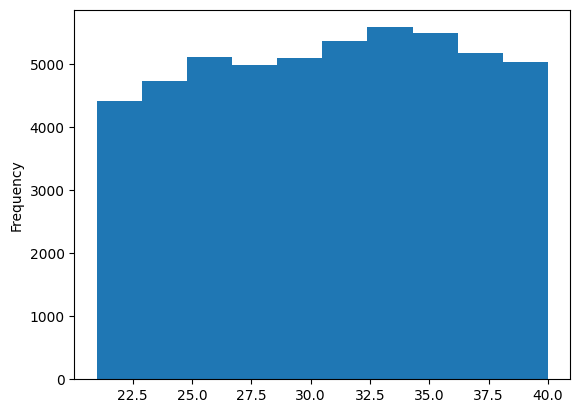

In [15]:
df_processed[df_processed['popularity_multiclass']==2]['popularity'].plot(kind='hist')


<Axes: ylabel='Frequency'>

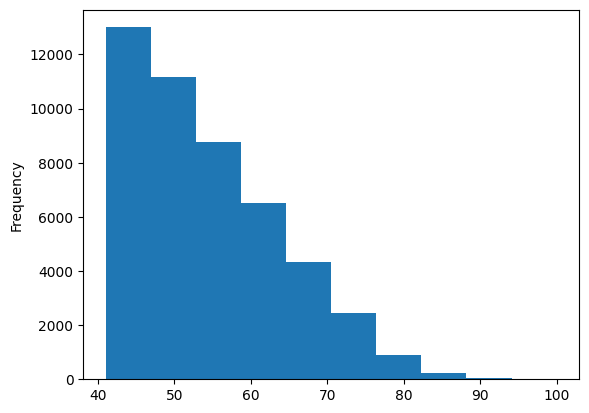

In [16]:
df_processed[df_processed['popularity_multiclass']==3]['popularity'].plot(kind='hist')


<Axes: ylabel='Frequency'>

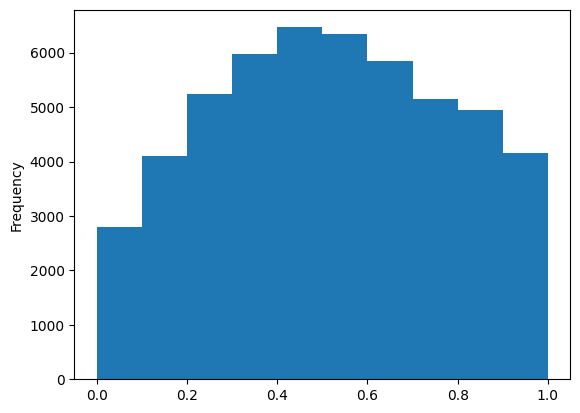

In [17]:
df_processed[df_processed['popularity_multiclass']==2]['energy'].plot(kind='hist')


<Axes: ylabel='Frequency'>

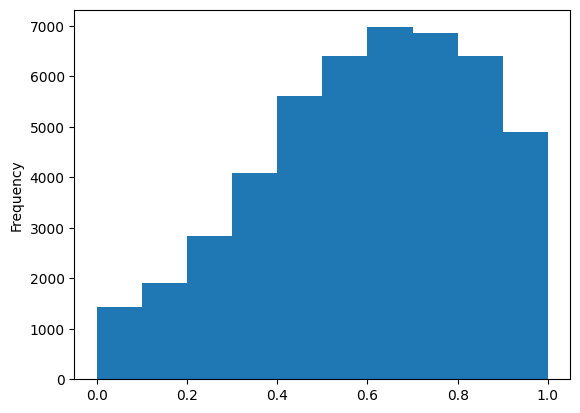

In [18]:
df_processed[df_processed['popularity_multiclass']==3]['energy'].plot(kind='hist')


<Axes: ylabel='Frequency'>

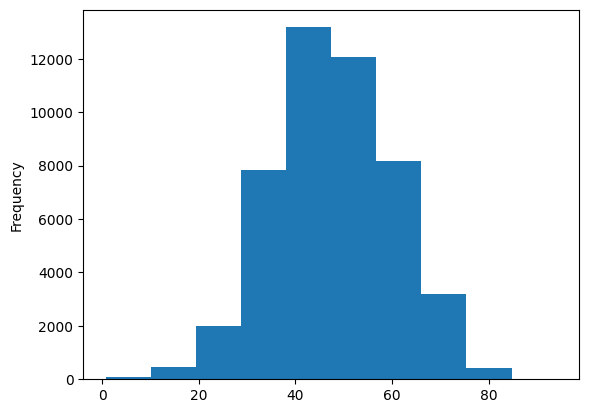

In [19]:
df_processed[df_processed['popularity_multiclass']==3]['popularity_ar'].plot(kind='hist')


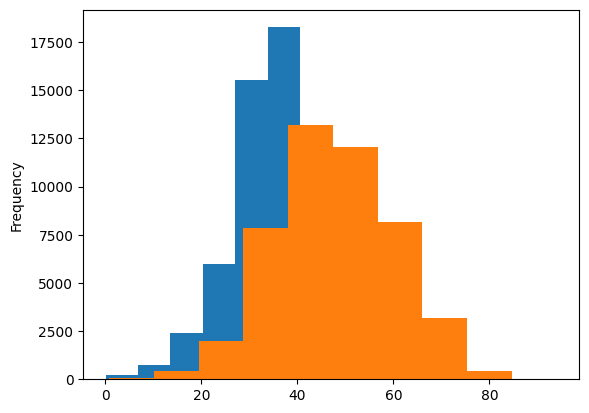

In [20]:
df_processed[df_processed['popularity_multiclass']==2]['popularity_ar'].plot(kind='hist')
df_processed[df_processed['popularity_multiclass']==3]['popularity_ar'].plot(kind='hist')
#df_processed[df_processed['popularity_multiclass']==1]['popularity_ar'].plot(kind='hist')
#df_processed[df_processed['popularity_multiclass']==0]['popularity_ar'].plot(kind='hist')
plt.show()


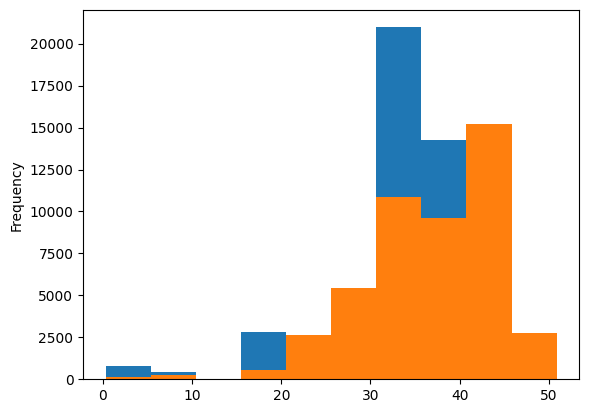

In [21]:
df_processed[df_processed['popularity_multiclass']==2]['popularity_yr'].plot(kind='hist')
df_processed[df_processed['popularity_multiclass']==3]['popularity_yr'].plot(kind='hist')
#df_processed[df_processed['popularity_multiclass']==1]['popularity_yr'].plot(kind='hist')
#df_processed[df_processed['popularity_multiclass']==0]['popularity_yr'].plot(kind='hist')
plt.show()


<Axes: ylabel='Frequency'>

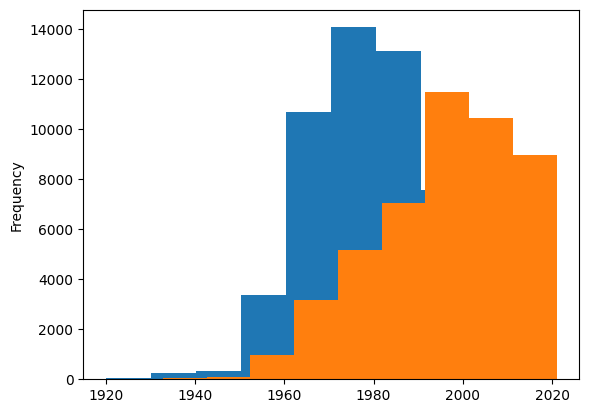

In [22]:
df_processed[df_processed['popularity_multiclass']==2]['year'].plot(kind='hist')
df_processed[df_processed['popularity_multiclass']==3]['year'].plot(kind='hist')

In [84]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_mutual_info_score,adjusted_rand_score
scaler = StandardScaler()
df_train = df_processed[[x for x in df_processed.columns if x !='popularity_multiclass']]
y = df_processed['popularity_multiclass']
kmeas = KMeans(n_clusters=4)
X_scaled = scaler.fit_transform(df_train)
cluster_labels = kmeas.fit_predict(X_scaled)

In [85]:
ari = adjusted_rand_score(y,cluster_labels)
ami = adjusted_mutual_info_score(y,cluster_labels)

print(ari)
print(ami)

0.3277107191332529
0.3941183159236421


In [74]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


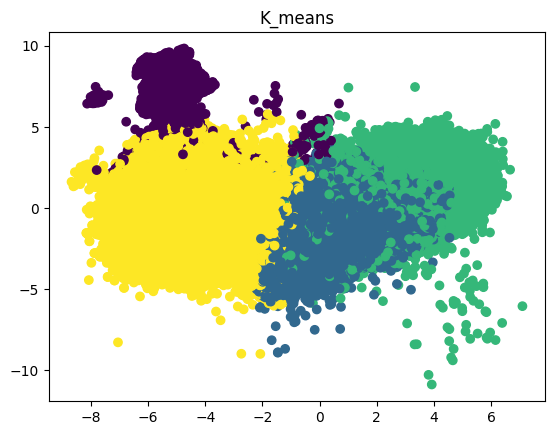

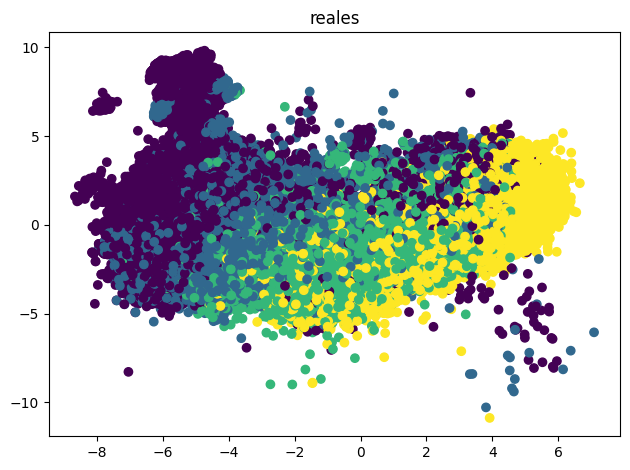

In [75]:

plt.scatter(X_pca[:,0],X_pca[:,1],c=cluster_labels,cmap='viridis')
plt.title("K_means")
plt.show()
plt.scatter(X_pca[:,0],X_pca[:,1],c=y,cmap='viridis')
plt.title("reales")
plt.tight_layout()
plt.show()

In [81]:
df.columns

Index(['acousticness', 'danceability', 'duration_ms', 'energy', 'explicit',
       'instrumentalness', 'liveness', 'loudness', 'popularity', 'speechiness',
       'tempo', 'valence', 'year', 'key_0', 'key_1', 'key_2', 'key_3', 'key_4',
       'key_5', 'key_6', 'key_7', 'key_8', 'key_9', 'key_10', 'key_11',
       'minor', 'major', 'acousticness_ar', 'danceability_ar',
       'duration_ms_ar', 'energy_ar', 'instrumentalness_ar', 'liveness_ar',
       'loudness_ar', 'speechiness_ar', 'tempo_ar', 'valence_ar',
       'popularity_ar', 'count', 'key_0_ar', 'key_1_ar', 'key_2_ar',
       'key_3_ar', 'key_4_ar', 'key_5_ar', 'key_6_ar', 'key_7_ar', 'key_8_ar',
       'key_9_ar', 'key_10_ar', 'key_11_ar', 'minor_ar', 'major_ar',
       'acousticness_yr', 'danceability_yr', 'duration_ms_yr', 'energy_yr',
       'instrumentalness_yr', 'liveness_yr', 'loudness_yr', 'speechiness_yr',
       'tempo_yr', 'valence_yr', 'popularity_yr', 'key_0_yr', 'key_1_yr',
       'key_2_yr', 'key_3_yr', 'key_4_yr',